In [1]:
import numpy as np
import matplotlib.pyplot as plt
import process_data as pd
import frequency_func as ff
from scipy.optimize import curve_fit
import pandas
plt.rcParams['text.usetex'] = True
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

In [2]:
outfile_name="../QKE_data/72-QKE_32_1_coh8.csv"
epsilon_name="../QKE_data/72-QKE_32_1_coh8-eps.csv"
data_full=pd.make_data_dictionary(outfile_name, epsilon_name)

In [3]:
Tcm=data_full['Tcm']
dm2=1e-18 
ke=0.9
km=1.8
B=np.array([0.8,0,-0.6])
B_lin=np.linspace(0,1,5)
ax_lin=np.linspace(-1,1,5)
A_const=0.9/np.max((ke**3,km**3))
eps = data_full['eps']
w=data_full['w']
time_f=data_full['time']
eps0=2.310490601866484 #ke=0.9,km=1.8
fsf=data_full['f']

In [4]:
name_quant='km'
pd.run_coherentsolve(name_quant, Tcm, dm2, ke, km, ke, km)
data_quant=ff.return_data(name_quant)
time_q=data_quant['time']

In [5]:
eps_s=15
eps_b=45
# set e = eps_s or eps_b

In [6]:
P0f, Pxf, Pyf, Pzf = pd.make_P(data_full['rho'])
P0barf, Pxbarf, Pybarf, Pzbarf = pd.make_P(data_full['rhobar'])

Sf=np.array([(P0f*Pxf)+(P0barf*Pxbarf),(P0f*Pyf)+(P0barf*Pybarf),(P0f*Pzf)+(P0barf*Pzbarf)])
B_anglef=np.empty((len(time_f),len(eps)),dtype=float)
rf=np.empty((len(time_f),len(eps)))     
for e in range(len(eps)):
    for t in range(len(time_f)):
        B_anglef[t,e]=np.dot(B,Sf[:,t,e])/np.linalg.norm(Sf[:,t,e])
        rf[t,e]=P0f[t,e]*np.sqrt(Pxf[t,e]**2+Pzf[t,e]**2+Pyf[t,e]**2)
        
Vs=pd.V_mat(data_full)
Vyf=Vs[1]
D = np.diff(B_anglef[:,-1])
D_sign = np.sign(D)
switch=np.diff(D_sign)
extf=np.array([],dtype='int')
for i in range(len(D_sign)-1):
    if switch[i]!=0:
        extf=np.append(extf,i)
# V_maxf=V_extf[::4] #2 sign changes per cycle #for eps=10.0

freqf=2*np.pi*pd.hbar*1e6/np.diff(time_f[extf[::4]])
for p in range(len(extf[1::4])):
    if B_anglef[extf[1::4][p],eps_s]>0.999:
        switch_pt=p
        break

In [7]:
P0q, Pxq, Pyq, Pzq = pd.make_P(data_quant['rho'])
P0barq, Pxbarq, Pybarq, Pzbarq = pd.make_P(data_quant['rhobar'])
Sq=np.array([(P0q*Pxq)+(P0barq*Pxbarq),(P0q*Pyq)+(P0barq*Pybarq),(P0q*Pzq)+(P0barq*Pzbarq)])
S0q=np.array(np.sqrt(Sq[0,0]**2+Sq[1,0]**2+Sq[2,0]**2))
B_angleq=np.empty((len(time_q),len(eps)),dtype=float)
rq=np.empty((len(eps)))
integrand=0
wn=0.5*np.sqrt(2)*pd.GF*(Tcm**2)*dm2*A_const*(ke-km)/(np.pi**2) # is negative because ke<km
for e in range(len(eps)):
    for t in range(len(time_q)):
        B_angleq[t,e]=np.dot(B,Sq[:,t,e])/np.linalg.norm(Sq[:,t,e])
    rq[e]=np.sqrt(Pxq[0,e]**2+Pzq[0,e]**2)
    integrand+=w[e]*eps[e]*S0q[e]*np.sign(B_angleq[0,e])*-1 
integral=integrand*np.sqrt(2)*pd.GF*(Tcm**2)*dm2*0.25/(np.pi**2)   
    
Vs=pd.V_mat(data_quant)
Vyq=Vs[1]
freq=ff.frequency(data_quant,dm2)
co0q=freq[1]
afq=freq[3]
fsq=data_quant['f']

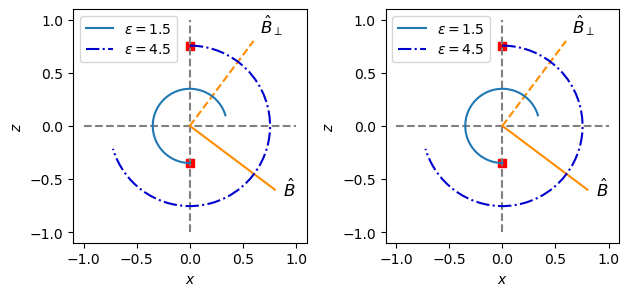

In [8]:
fig,(ax1,ax2)=plt.subplots(1,2)

ax1.set_box_aspect(1)
ax1.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
ax1.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
ax1.plot(B_lin*B[0],B_lin*B[2],color='darkorange')
ax1.plot(B_lin*-1*B[2],B_lin*B[0],'--',color='darkorange')
ax1.text(B[0]*1.1,B[2]*1.1,'$\hat{B}$',size='large')
ax1.text(B[2]*-1.1,B[0]*1.1,'$\hat{B}_\perp$',size='large')
ax1.set_xlabel('$x$')
ax1.set_ylabel('$z$')
ax1.plot(Pxq[:co0q[2],eps_s],Pzq[:co0q[2],eps_s],label='$\epsilon=1.5$',color='C0')
ax1.scatter(Pxq[0,eps_s],Pzq[0,eps_s],marker='s',color='red')
ax1.plot(Pxq[:co0q[2],eps_b],Pzq[:co0q[2],eps_b],'-.',label='$\epsilon=4.5$',color='mediumblue')
ax1.scatter(Pxq[0,eps_b],Pzq[0,eps_b],marker='s',color='red')
ax1.legend()

ax2.set_box_aspect(1)
ax2.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
ax2.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
ax2.plot(B_lin*B[0],B_lin*B[2],color='darkorange')
ax2.plot(B_lin*-1*B[2],B_lin*B[0],'--',color='darkorange')
ax2.text(B[0]*1.1,B[2]*1.1,'$\hat{B}$',size='large')
ax2.text(B[2]*-1.1,B[0]*1.1,'$\hat{B}_\perp$',size='large')
ax2.set_xlabel('$x$')
ax2.set_ylabel('$z$')
ax2.plot(Pxq[:co0q[2],eps_s],Pzq[:co0q[2],eps_s],label='$\epsilon=1.5$',color='C0')
ax2.scatter(Pxq[0,eps_s],Pzq[0,eps_s],marker='s',color='red')
ax2.plot(Pxq[:co0q[2],eps_b],Pzq[:co0q[2],eps_b],'-.',label='$\epsilon=4.5$',color='mediumblue')
ax2.scatter(Pxq[0,eps_b],Pzq[0,eps_b],marker='s',color='red')
ax2.legend()

plt.tight_layout()

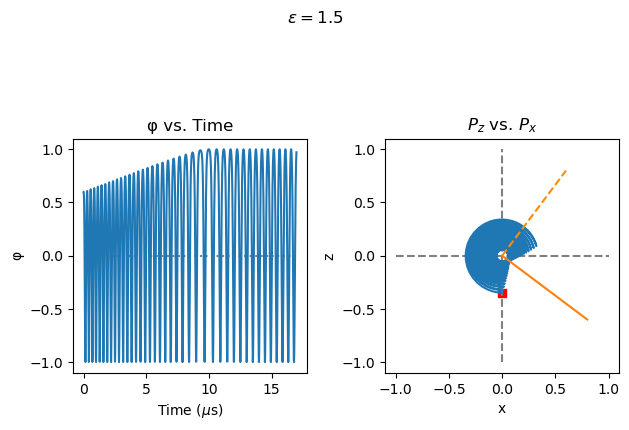

In [9]:
e=eps_s
fig,(ax1,ax2)=plt.subplots(1,2)
fig.suptitle('$\epsilon=$'+str(eps[e]))

ax1.set_box_aspect(1)
ax1.set_title('φ vs. Time')
ax1.set_xlabel('Time ($\mu$s)')
ax1.set_ylabel('φ')
ax1.plot(np.linspace(0,time_f[-1],2),[0]*2,':',color='gray')
ax1.plot(time_f,B_anglef[:,e])
# ax1.scatter(time_f[extf[1::4]],B_anglef[extf[1::4],e])
# plt.scatter(time_f[extf[1::4]],B_anglef[extf[1::4],e])
# plt.xlim(10,17.5)

ax2.set_box_aspect(1)
ax2.set_title('$P_z$ vs. $P_x$')
ax2.set_xlabel('x')
ax2.set_ylabel('z')
ax2.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
ax2.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
ax2.plot(Pxf[:,e],Pzf[:,e])
ax2.plot(B_lin*B[0],B_lin*B[2],label='B')
ax2.plot(B_lin*-1*B[2],B_lin*B[0],'--',label='B⊥',color='darkorange')
ax2.scatter(Pxf[0,e],Pzf[0,e],color='red',marker='s')
# plt.scatter(Pxf[extf[::4],e],Pzf[extf[::4],e])
# plt.scatter(Pxf[extf[1::4],e],Pzf[extf[1::4],e])

plt.tight_layout()

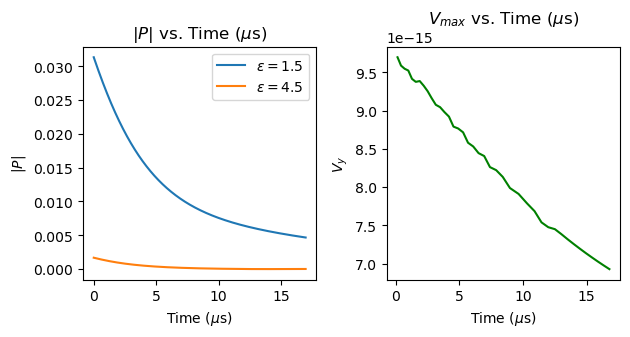

In [10]:
fig,(ax1,ax2)=plt.subplots(1,2)
# fig.suptitle('|P| over time for epsilon')

#this looks different from original, check
ax1.set_box_aspect(1)
ax1.set_title('$|P|$ vs. Time ($\mu$s)')
ax1.set_xlabel('Time ($\mu$s)')
ax1.set_ylabel('$|P|$')
ax1.plot(time_f,rf[:,eps_s],label='$\epsilon=$'+str(eps[eps_s]))
ax1.plot(time_f,rf[:,eps_b],label='$\epsilon=$'+str(eps[eps_b]))
# ax1.plot(time_f,rf[:,100],label=eps[100])
# ax1.plot(time_f,rf[:,10],label=eps[10])
# ax1.scatter(time_f[extf[1::4][switch_pt-1]],np.abs(rf[extf[2::4][switch_pt-1],eps_s]),color='purple')
# ax1.scatter(time_f[extf[1::4][switch_pt-1]],np.abs(rf[extf[2::4][switch_pt-1],eps_b]),color='purple')
ax1.legend()

ax2.set_box_aspect(1)
ax2.set_title('$V_{max}$ vs. Time ($\mu$s)')
ax2.set_xlabel('Time ($\mu$s)')
ax2.set_ylabel('$V_y$')
# ax2.plot(time_f[extf[::4]],Vyf[extf[::4]],color='green',label='|V|max')
# ax2.plot(time_f[extf[2::4]],Vyf[extf[2::4]],color='green',label='|V|max')
ax2.plot(time_f[extf[::2]],np.abs(Vyf[extf[::2]]),color='green',label='|V|max')
# ax2.scatter(time_f[extf[2::4][switch_pt-1]],np.abs(Vyf[extf[2::4][switch_pt-1]]),color='purple')

fig.tight_layout()

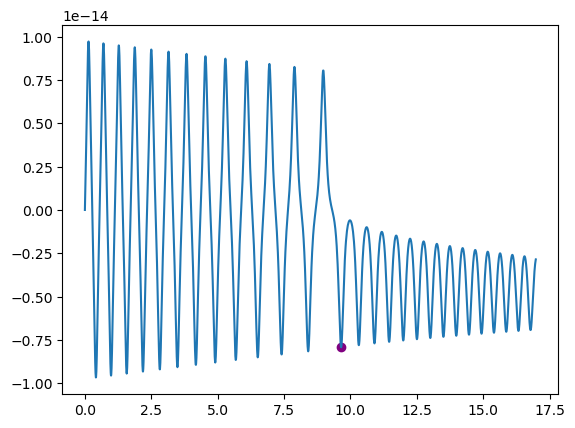

In [11]:
plt.plot(time_f,Vyf)
# plt.scatter(time_f[extf[::4]],Vyf[extf[::4]])
# plt.scatter(time_f[extf[2::4]],Vyf[extf[2::4]])
# plt.scatter(time_f[extf[1::4]],Vyf[extf[1::4]])
plt.scatter(time_f[extf[2::4][switch_pt-1]],Vyf[extf[2::4][switch_pt-1]],color='purple')

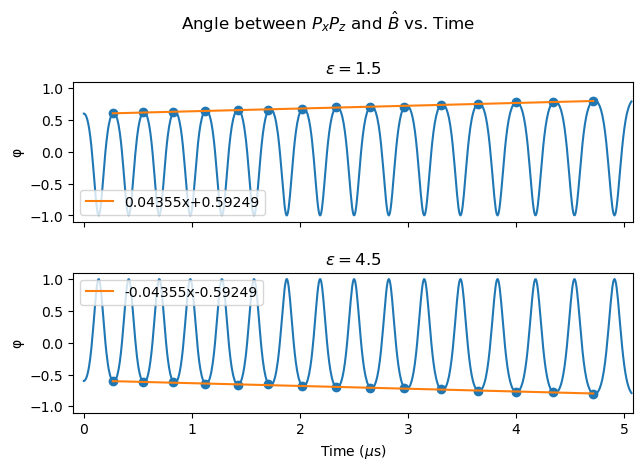

In [28]:
def model(x,m,b):
    return m*x+b

fig,(ax1,ax2)=plt.subplots(2,1,sharex=True)
plt.suptitle('Angle between $P_xP_z$ and $\hat{B}$ vs. Time')

ax1.set_box_aspect(0.25)
fit= curve_fit(model,time_f[extf[1::2][:switch_pt]],B_anglef[extf[1::2]][:switch_pt,eps_s])
ans,cov=fit
y_data=model(time_f[extf[1::2][:switch_pt+2]],ans[0],ans[1])
ax1.set_title('$\epsilon=$'+str(eps[eps_s]))
ax1.plot(time_f[:extf[1::2][switch_pt+2]],B_anglef[:extf[1::2][switch_pt+2],eps_s])
ax1.plot(time_f[extf[1::2][:switch_pt+2]],y_data,label=str(ans[0])[:7]+'x+'+str(ans[1])[:7])
ax1.scatter(time_f[extf[1::2][:switch_pt+2]],B_anglef[extf[1::2][:switch_pt+2],eps_s])
# plt.scatter(time[cycle[:cyc_i]],cos[:cyc_i,eps_s])
ax1.set_xlim(-0.1,time_f[extf[1::2][switch_pt+2]])
ax1.set_ylim(-1.1,1.1)
ax1.legend(loc=3)
ax1.set_ylabel('φ')

ax2.set_box_aspect(0.25)
fit= curve_fit(model,time_f[extf[1::2][:switch_pt]],B_anglef[extf[1::2]][:switch_pt,eps_b])
ans,cov=fit
y_data=model(time_f[extf[1::2][:switch_pt+2]],ans[0],ans[1])
ax2.set_title('$\epsilon=$'+str(eps[eps_b]))
ax2.plot(time_f[:extf[1::2][switch_pt+2]],B_anglef[:extf[1::2][switch_pt+2],eps_b])
ax2.plot(time_f[extf[1::2][:switch_pt+2]],y_data,label=str(ans[0])[:8]+'x'+str(ans[1])[:8])
ax2.scatter(time_f[extf[1::2][:switch_pt+2]],B_anglef[extf[1::2][:switch_pt+2],eps_b])
# plt.scatter(time[cycle[:cyc_i]],cos[:cyc_i,eps_s])
ax2.set_xlim(-0.1,time_f[extf[1::2][switch_pt+2]])
ax2.set_ylim(-1.1,1.1)
ax2.legend(loc=2)
ax2.set_xlabel('Time ($\mu$s)')
ax2.set_ylabel('φ')

# fig.supxlabel('Time ($\mu$s)')
# fig.supylabel('φ')
fig.tight_layout()


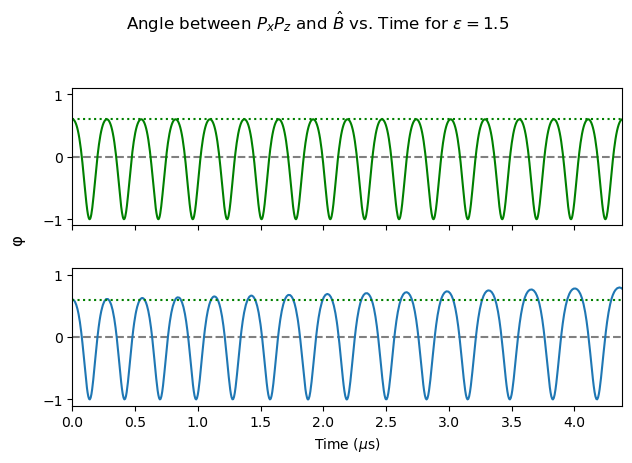

In [24]:
e=eps_s
fig,(ax1,ax2)=plt.subplots(2,1,sharex=True)
plt.suptitle('Angle between $P_xP_z$ and $\hat{B}$ vs. Time for $\epsilon=$'+str(eps[e]))

ax1.set_box_aspect(0.25)
ax1.plot(np.linspace(0,time_q[-1],2),[0]*2,'--',color='gray')
ax1.plot(time_q,B_angleq[:,e],color='green',label='quantum')
ax1.plot(time_q,[0.6]*len(time_q),':',color='green')
ax1.set_xlim(0,time_q[-1])
ax1.set_ylim(-1.1,1.1)

ax2.set_box_aspect(0.25)
ax2.plot(np.linspace(0,time_q[-1],2),[0]*2,'--',color='gray')
ax2.plot(time_f,B_anglef[:len(time_f),e],color='C0', label='full')
ax2.plot(time_q,[0.6]*len(time_q),':',color='green')
# ax2.scatter(time_f[V_maxf],B_anglef[V_maxf,e])
ax2.set_xlim(0,time_q[-1])
ax2.set_ylim(-1.1,1.1)

ax2.set_xlabel('Time ($\mu$s)')
fig.supylabel('φ')
plt.tight_layout()

In [14]:
# plt.figure(figsize=(5,5))
# plt.title('Pz vs. Px for eps='+str(eps[eps_b]))
# plt.plot(ax_lin,[0]*len(ax_lin),'--',color='gray')
# plt.plot([0]*len(ax_lin),ax_lin,'--',color='gray')
# plt.plot(Pxq[:,eps_b],Pzq[:,eps_b],color='green',label='quantum')
# plt.plot(Pxf[:len(time_q),eps_b],Pzf[:len(time_q),eps_b],color='C0',label='full')
# plt.scatter(Pxq[0,eps_b],Pzq[0,eps_b],color='red',marker='s')
# plt.plot(B_lin*B[0],B_lin*B[2],label='B',color='darkorange')
# plt.plot(B_lin*-1*B[2],B_lin*B[0],'--',label='B⊥',color='darkorange')
# plt.xlabel('x')
# plt.ylabel('z')
# plt.legend()

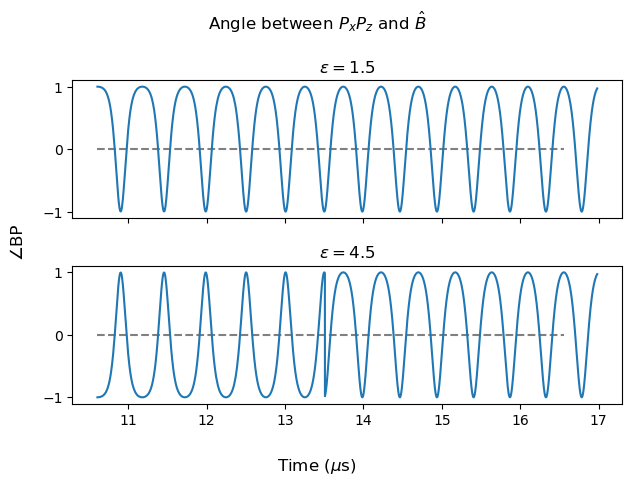

In [15]:
fig,(ax1,ax2)=plt.subplots(2,1,sharex=True,sharey=True)
plt.suptitle('Angle between $P_xP_z$ and $\hat{B}$')

ax1.set_box_aspect(0.25)
ax1.set_title('$\epsilon=$'+str(eps[eps_s]))
ax1.plot(time_f[extf[1::2][switch_pt*2:]],[0]*len(time_f[extf[1::2][switch_pt*2:]]),'--',color='gray')
ax1.plot(time_f[extf[1::2][switch_pt*2]:],B_anglef[extf[1::2][switch_pt*2]:,eps_s])

ax2.set_box_aspect(0.25)
ax2.set_title('$\epsilon=$'+str(eps[eps_b]))
ax2.plot(time_f[extf[1::2][switch_pt*2:]],[0]*len(time_f[extf[1::2][switch_pt*2:]]),'--',color='gray')
ax2.plot(time_f[extf[1::2][switch_pt*2]:],B_anglef[extf[1::2][switch_pt*2]:,eps_b])

fig.supxlabel('Time ($\mu$s)')
fig.supylabel('φ')
plt.tight_layout()

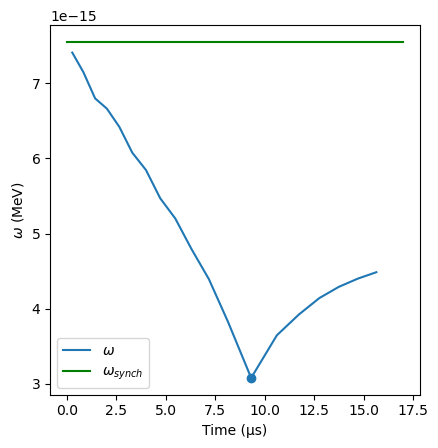

In [33]:
fig,ax=plt.subplots()
# plt.title('Oscillation Frequency ($\omega_{synch}$) vs Time')
ax.set_box_aspect(1)
ax.set_xlabel('Time (μs)')
ax.set_ylabel('$\omega$ (MeV)')
ax.plot(time_f[extf[1::4][:-1]],freqf,label='$\omega$')
ax.plot(time_f[::10],[afq]*len(time_f[::10]),color='green',label='$\omega_{synch}$')
ax.scatter(time_f[extf[1::4][switch_pt-1]],freqf[switch_pt-1])

ax.legend()

In [17]:
pd.run_coherentsolve(name_quant, Tcm, dm2, km, ke, km, ke) # need to change file name if further qantum analysis graphs needed
data_inv=ff.return_data(name_quant)
time_inv=data_inv['time']
fs_inv=data_inv['f']

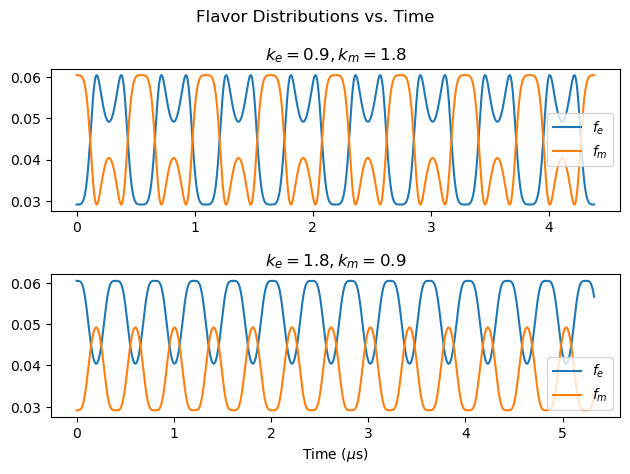

In [18]:
e=eps_s
fig,(ax1,ax2)=plt.subplots(2,1)
plt.suptitle('Flavor Distributions vs. Time')

ax1.set_title('$k_e=0.9,k_m=1.8$')
ax1.set_box_aspect(0.25)
ax1.plot(time_q,fsq[0][:,e],label='$f_e$')
ax1.plot(time_q,fsq[1][:,e],label='$f_m$')
ax1.legend()

ax2.set_title('$k_e=1.8,k_m=0.9$')
ax2.set_box_aspect(0.25)
ax2.set_xlabel('Time ($\mu$s)')
ax2.plot(time_inv,fs_inv[0][:,e],label='$f_e$')
ax2.plot(time_inv,fs_inv[1][:,e],label='$f_m$')
ax2.legend(loc=4)

# fig.supylabel('f')
# fig.supxlabel('Time')
plt.tight_layout()

In [19]:
print(time_q)

[0.00000000e+00 6.58200000e-08 3.94920000e-07 ... 4.36981907e+00
 4.37525442e+00 4.38044277e+00]


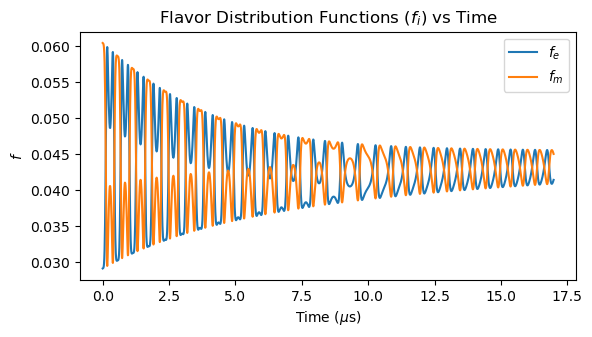

In [20]:
e=eps_s
fig,ax=plt.subplots()
# ax.set_box_aspect(1)

ax.set_box_aspect(0.5)
ax.set_title('Flavor Distribution Functions ($f_i$) vs Time')
ax.set_xlabel('Time ($\mu$s)')
ax.set_ylabel('$f$')
ax.plot(time_f,fsf[0][:,e],label='$f_e$')
ax.plot(time_f,fsf[1][:,e],label='$f_m$')
ax.legend(loc=1)

(0.0, 4.380442765105849)

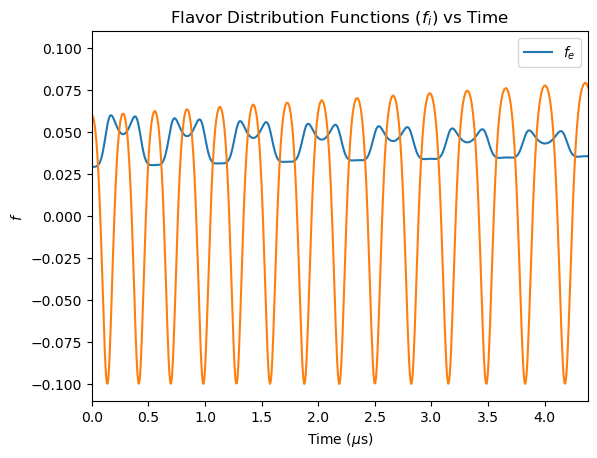

In [21]:
e=eps_s
fig,ax=plt.subplots()
# ax.set_box_aspect(1)

ax.set_title('Flavor Distribution Functions ($f_i$) vs Time')
ax.set_xlabel('Time ($\mu$s)')
ax.set_ylabel('$f$')
ax.plot(time_f,fsf[0][:,e],label='$f_e$')
# ax.plot(time_q,fsq[0][:,e],label='$f_e$')
ax.plot(time_f,0.1*B_anglef[:,e])
ax.legend()
ax.set_xlim(0,time_q[-1])